In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import wandb
import torch
from accelerate.test_utils.testing import get_backend
from lightning.pytorch.loggers import WandbLogger
from lightning import Trainer
from core.data import FullBatchDataModule
from core.estimators import BiasWithMSE
from core.models import KernelRegression, NoisyMLP
from functools import partial
from lightning.pytorch import LightningModule, Trainer
from torch.func import functional_call
from core.entk import compute_empirical_ntk
device, n_devices, mem = get_backend()
torch.set_float32_matmul_precision("highest")

# NTK with Kernel Regression

In [2]:
torch.manual_seed(42)
n = 100
p = 10
# model = LinearNetwork(input_dim=p, output_dim=1, hidden_dim=1000)
model = NoisyMLP(in_features=p, 
                 out_features=1, 
                 hidden_features=1000, 
                 num_hidden_layers=3,
                 dropout_rate=0.,
                 loss_func=torch.nn.MSELoss(),
                 lr=1e-4)
# for param in model.parameters():
#     torch.nn.init.normal_(param, mean=0.0, std=100.)
model = model.to(device)
loss_fn = torch.nn.MSELoss()

# Data generation
X = torch.randn(n, p, device=device)
y = X @ torch.randn(p, 1, device=device) + 0.1 *torch.randn(n, 1, device=device)
dm = FullBatchDataModule(X, y, num_workers=0)


# setup for torch.func.functional_call
# detach parameters to avoid accidental backpropagation through the model
detached_params = {k: v.detach() for k, v in model.named_parameters()}
# params = dict(model.named_parameters()) # potentially uncomment if you need to backprop through the model. maybe unsafe?
def model_call(params, x):
    """ Calls the model with the given parameters and a single input x."""
    return functional_call(model, params, (x.unsqueeze(0),)).squeeze(0)


In [3]:
ntk_matrix_full = compute_empirical_ntk(
        model_call, detached_params, X, X, compute='full'
    ) # Shape: (n_1, n_2, output_dim, output_dim)
K = ntk_matrix_full.squeeze() # Shape: (n_1, n_2)
K_inv = torch.linalg.inv(K)
assert torch.allclose(K @ K_inv, torch.eye(n, device=device), atol=1e-3), "K is not invertible"
# match the initial kernel regression weights to the network's initial weights (they should make the same predictions)
init_predictions = model(X)  # Shape: (n, output_dim)
alpha_init = (K_inv @ init_predictions.squeeze()).detach().clone()  # Shape: (n, output_dim)
assert torch.allclose(init_predictions.view(-1), K @ alpha_init, atol=1e-6), "Initial predictions do not match"

/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [6]:
# # set seed for reproducibility
# torch.manual_seed(42)
# alpha = torch.nn.Parameter(alpha_init.clone().detach()) # α ∈ ℝ^n
# print(f'Initial norm of alpha: {alpha.norm().item()}')
# alpha.register_hook(lambda grad: K_inv @ grad)  # Hook to apply natural gradient
# opt = torch.optim.SGD([alpha], lr=1e-3)
# steps = 1000

# for i in range(steps):
#     opt.zero_grad()

#     pred = K @ alpha                 # f(X)
#     loss = torch.nn.functional.mse_loss(pred, y.squeeze())  # L(f(X), y)
#     loss.backward()                          # grad = K (Kα - y)
#     with torch.no_grad():
#         # This is the natural gradient step: α = K_inv @ (Kα - y)
#         if i % 100 == 0:
#             print(f"{30 * '='} Step {i}/{steps} {30 * '='}")
#             print(f'Norm of alpha.grad: {alpha.grad.norm().item()}')
#             print(f'Loss at step {i}: {loss.item()}')

#         # alpha.grad.copy_(K_inv @ alpha.grad)
#     opt.step()
# print(f'\nFinal loss: {loss.item()}')

### Fit neural network

In [4]:
# from lightning.pytorch.loggers import CSVLogger
logger = WandbLogger(save_dir='../logs', name='nonlinear_network_ntk', project='inductive-bias')
train = Trainer(
    max_epochs=1,
    accumulate_grad_batches=1,
    accelerator=device,
    log_every_n_steps=1,
    logger=logger,
)
train.fit(model, datamodule=dm)
wandb.finish()

/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/anon/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize the

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | loss_func | MSELoss    | 0      | train
1 | layers    | Sequential | 2.0 M  | train
-------------------------------------------------
2.0 M     Trainable params
0         Non-trainable params
2.0 M     Total params
8.056     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


epoch,▁
train/loss,▁
trainer/global_step,▁
epoch,0
train/loss,3.48902
trainer/global_step,0


### Fitting Kernel Regression

In [5]:
kernel_reg = KernelRegression(
    kernel = K.clone().detach(),  # Use the computed kernel matrix
    n_train_samples= n,
    ridge_lambda=0.,
    fit_intercept=False,
    init_zeros=False,
    init_weights=alpha_init.clone().detach().view(1,-1),  # Flatten the initial weights
    lr=1e-4,
)
# Register a hook to apply natural gradient instead of standard gradient
kernel_reg.kernel_linear.weight.register_hook(lambda grad: (K_inv @ grad.squeeze(0)).unsqueeze(0))  

logger = WandbLogger(save_dir='../logs', name='ntk_kernel_regression', project="inductive-bias")
kernel_train = Trainer(
    max_epochs=1,
    accumulate_grad_batches=1,
    accelerator=device,
    log_every_n_steps=1,
    logger=logger,
)
kernel_train.fit(kernel_reg, datamodule=dm)
last_epoch_krr = kernel_train.current_epoch
wandb.finish()

core/models.py:264: UserWarning: Using a precomputed kernel. batch inputs will be ignored.
  warnings.warn("Using a precomputed kernel. batch inputs will be ignored.")
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/anon/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | kernel_linear | Linear             | 100    | train
1 | loss_func     | KernelRidgeMSELoss | 0      | train
-------------------------------------------------------------
100       Trainable params
0         Non-trainable params
100       Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


epoch,▁
train/loss,▁
trainer/global_step,▁
epoch,0
train/loss,3.48902
trainer/global_step,0


### Estimating the inductive bias

In [ ]:
# Estimate the quadratic form using the estimated Q from matrix ridge bias
from core.bias import DiagMatrixBiasNTKRR
from lightning.pytorch.callbacks import EarlyStopping
from core.callbacks import WandBCallback

## .detach() is essential here to detach the predictive model from the graph
# alpha_init = rbf_kernel_reg.init_weights.view(-1).detach().clone()

# Use vanilla MSE loss, additional regularization is handled by the bias model
ntk_estimator = BiasWithMSE(
    predictive_model=kernel_reg,
    bias_model=DiagMatrixBiasNTKRR(
        Q_t_init=None,  # will be initialized as zeros
        dim=n,
        t=last_epoch_krr, # use the last epoch of the kernel regression
        K=K,
        alpha_init=alpha_init.clone(),
        eta=1e-4,
        lambda_=0.,
    ),
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

wandb_logger = WandbLogger(
    project="inductive-bias", name="ntk-kernel-bias", log_model=False, save_dir='../logs'
)
ntk_trainer = Trainer(
    max_epochs=5000,
    accumulate_grad_batches=1,
    log_every_n_steps=5,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=50, mode="min"),
    ],
    accelerator="gpu",
    devices=n_devices,
)
ntk_trainer.fit(ntk_estimator, dm)

/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/anon/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                | Params | Mode 
-----------------------------------------------------------------
0 | predictive_model | KernelRegression    | 100    | train
1 | bias_model       | DiagMatrixBiasNTKRR | 100    | train
-----------------------------------------------------------------
200       Trainable params
0         Non-trainable params
200       Total params
0.001     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/py

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5000` reached.


bias/Q_t,▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████
bias/Q_t_grad,███▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch,▁▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇███
train/loss,██████▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
trainer/global_step,▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇██
bias/Q_t,497.30157
bias/Q_t_grad,0.05767
epoch,4999
train/loss,552.23206
trainer/global_step,4999


In [15]:
from typing import Optional
def compute_kernel_ridge_Q_omega(K: torch.Tensor, eta: float, t: int, lambda_: float, alpha_init: torch.Tensor, device: Optional[str] = None) -> torch.Tensor:
    """
    Compute the Q matrix for kernel ridge regression.
    """
    if device is None:
        device = K.device
    K = K.to(device)
    alpha_init = alpha_init.to(device)
    dim = K.shape[0]
    I = torch.eye(dim, device=device)
    D = (1. / dim) * K + lambda_ * I
    A = I - 2 * eta * D
    A_t = torch.linalg.matrix_power(A, t)
    Q_t = D @ (torch.linalg.inv(I - A_t) - I)

    omega_t = (D + Q_t) @ A_t @ alpha_init 

    return Q_t, omega_t

def compute_alpha_closed_form(K: torch.Tensor, y: torch.Tensor, Q: torch.Tensor, omega: torch.Tensor, lambda_: float) -> torch.Tensor:
    """
    Compute the closed-form solution for alpha using the kernel matrix K.
    """
    n = K.shape[0]
    C = (1 / n) * K @ K + lambda_ * K
    rhs = omega + (1 / n) * K @ y
    lhs = C + Q
    alpha = torch.linalg.solve(lhs, rhs)
    return alpha

def compute_implied_Q_diagonal(K: torch.Tensor, y: torch.Tensor, eta: float, t: int, alpha: torch.Tensor, alpha_init: torch.Tensor) -> torch.Tensor:
    """
    Compute the exact Q matrix for kernel ridge regression.
    """
    n = K.shape[0]
    I = torch.eye(n, device=K.device)
    C = (1. / n) * (K @ K) + eta * K
    A = I - 2 * eta * C
    A_t = torch.linalg.matrix_power(A, t)
    Q_t = (C @ (A_t @ alpha_init - alpha) + (1. / n) * K @ y).view(-1) / (alpha - A_t @ alpha_init).view(-1)
    return torch.diag(Q_t)

    

# def compute_alpha_closed_form(K: torch.Tensor, y: torch.Tensor, Q: torch.Tensor, omega: torch.Tensor, lambda_: float) -> torch.Tensor:
#     """
#     Compute the closed-form solution for alpha using the kernel matrix K.
#     """
#     n = K.shape[0]
#     C = (1 / n) * K + lambda_ * torch.eye(n, device=K.device)
#     rhs = omega.view(-1) + (1 / n) * y.view(-1)  # Ensure y is flattened
#     lhs = C + Q
#     alpha = torch.linalg.solve(lhs, rhs)
#     return alpha

# computations has to happen on the same device as the estimation or matrix computations
# will yield different results
Q_kernel_ridge, omega_kernel_ridge = compute_kernel_ridge_Q_omega(K, eta=1e-3, t=last_epoch_krr, lambda_=0., alpha_init=alpha_init, device=device)
Q_kernel_ridge = Q_kernel_ridge.detach().cpu().clone()
omega_kernel_ridge = omega_kernel_ridge.detach().cpu().clone()

In [16]:
alpha_t = kernel_reg.kernel_linear.weight.detach().cpu().clone().view(-1)
Q_t = ntk_estimator.bias_model.Q_t.detach().cpu().clone()

compute_implied_Q_diagonal(K.cpu(), y.cpu().view(-1), eta=1e-3, t=last_epoch_krr, alpha=alpha_t, alpha_init=alpha_init.cpu())

tensor([[-11851.8506,      0.0000,      0.0000,  ...,      0.0000,
              0.0000,      0.0000],
        [     0.0000,  -7136.2915,      0.0000,  ...,      0.0000,
              0.0000,      0.0000],
        [     0.0000,      0.0000, -20553.1738,  ...,      0.0000,
              0.0000,      0.0000],
        ...,
        [     0.0000,      0.0000,      0.0000,  ...,  -8000.1899,
              0.0000,      0.0000],
        [     0.0000,      0.0000,      0.0000,  ...,      0.0000,
         -13106.7510,      0.0000],
        [     0.0000,      0.0000,      0.0000,  ...,      0.0000,
              0.0000,  -7603.5981]])

In [8]:
theory_alpha = compute_alpha_closed_form(K.cpu(), y.cpu().view(-1), Q_kernel_ridge, omega_kernel_ridge, lambda_=0.)
estimated_Q = ntk_estimator.bias_model.Q_t.detach().clone()
estimated_alpha = compute_alpha_closed_form(K.cpu(), y.cpu().view(-1), estimated_Q, omega_kernel_ridge, lambda_=0.)

In [9]:
theory_alpha

tensor([ 5.3335e-04, -8.6737e-04,  6.7203e-03,  3.0378e-03,  3.1637e-03,
        -1.1363e-03, -5.0700e-03, -3.7954e-04, -8.3700e-03,  3.3587e-03,
         1.6999e-03, -4.7188e-03, -1.3865e-03, -6.7554e-03, -4.8649e-03,
         5.6210e-03,  2.4917e-03, -7.4548e-04,  2.6470e-03,  9.5055e-04,
         2.1787e-03,  1.9541e-03,  4.0631e-03, -2.1235e-03, -4.9511e-06,
         1.5466e-03,  5.0334e-03, -6.8403e-03, -4.1795e-03,  6.5154e-05,
        -2.8231e-03, -4.8677e-03, -3.7049e-03,  4.1315e-03,  1.2315e-03,
         2.0852e-03,  4.0287e-03, -2.0684e-03, -3.7295e-03, -8.6906e-04,
         2.3053e-03, -7.3831e-03,  6.8686e-03,  5.1540e-03,  4.0491e-03,
        -4.1672e-03, -8.2790e-04, -3.8029e-03, -8.0694e-03,  2.0159e-03,
        -3.1053e-03, -4.3452e-03,  6.9309e-03,  2.6519e-03,  5.8848e-03,
         2.3617e-03, -3.9783e-03,  4.2500e-03,  5.4396e-03, -1.5439e-03,
        -1.7593e-03,  3.4610e-04, -2.1635e-03,  1.6074e-03,  6.0009e-04,
        -3.0871e-03,  5.0668e-03,  5.1478e-03, -6.1

In [10]:
estimated_alpha

tensor([-1.1172e+00,  6.6641e+00,  2.5345e+00,  7.4930e-01,  3.4866e+01,
        -2.1614e+01, -1.2469e+01,  1.3133e+00, -4.9116e+01,  2.1281e+01,
        -3.5470e+00, -5.7118e+00,  5.4592e-01, -4.3814e-01,  4.2814e+00,
         2.4009e+00, -9.1137e-01, -8.6934e-01, -2.9557e-01,  5.7743e+00,
        -4.6193e-01, -3.6211e+00, -6.8167e-01, -4.3326e+00, -2.7337e+00,
         7.6811e+00,  1.5366e+00, -4.1652e+01,  3.8239e-01, -1.5958e+00,
         7.4048e-01,  1.8493e+00,  1.3912e+00,  3.7377e+00, -9.8412e-01,
        -6.9242e+00,  1.0237e+01, -2.6614e+00,  4.1806e+00,  6.3035e+00,
         5.0836e+00,  1.6435e+00,  5.9560e-01,  6.8191e-02, -4.0965e+00,
        -1.4953e-01, -1.7219e+00, -1.1333e+01, -3.5180e+00,  5.6960e+00,
        -8.6549e+00,  2.3928e-01,  1.5172e+01,  6.1413e-01, -1.3819e+00,
        -1.6849e+00, -3.3936e+00,  2.9731e+00,  2.0438e+00, -7.9477e-01,
         2.7778e+00, -1.6703e+00, -1.9378e+00,  4.4457e+00, -6.7881e+00,
        -2.8867e+00, -7.0875e-01,  2.1358e+01,  1.4

# NTK linearization in original weight space


### Functional

In [3]:
import torch
from torch.func import jvp, functional_call
from torch.utils._pytree import tree_map

def linearize(module: torch.nn.Module, params: dict[str, torch.Tensor]):
    """
    Returns a function f_lin(new_params, *args, **kwargs) that is the first-order
    Taylor approximation of `module` around `params`.

    Args:
        module: An nn.Module. This is the model we want to linearize.
        params: A flat `dict[str, Tensor]` of parameters from the module, typically
                obtained via `dict(module.named_parameters())`.

    Returns:
        A function f_lin(new_params, *args, **kwargs) that computes the linearized
        output around `params`.
    """
    # track the parameter keys because torchopt expects a flat list of parameters
    # and we need to map them back to the original parameter names
    keys = list(dict(module.named_parameters()).keys())

    def f_lin(new_params: dict[str, torch.Tensor], *args, **kwargs):
        # Compute delta_params = new_params - params
        if not isinstance(new_params, dict):
            new_params = {k: v for k, v in zip(keys, new_params)}
        delta_params = {
            k: new_params[k] - params[k] for k in params
        }

        # Define a function that evaluates the module with given parameters
        def wrapped(p):
            return functional_call(module, p, args, kwargs)

        # Compute jvp of wrapped at `params` in the direction `delta_params`
        f_val, proj = jvp(wrapped, (params,), (delta_params,))

        # Return the first-order Taylor approximation
        if isinstance(f_val, dict):
            return {k: f_val[k] + proj[k] for k in f_val}
        elif isinstance(f_val, torch.Tensor):
            return f_val + proj
        else:
            raise TypeError(f"Unsupported output type: {type(f_val)}")

    return f_lin

Step   0 | Original Loss: 1.1695 | Linearized Loss: 1.1695
Step  10 | Original Loss: 1.0691 | Linearized Loss: 1.0690
Step  20 | Original Loss: 1.0201 | Linearized Loss: 1.0198
Step  30 | Original Loss: 0.9882 | Linearized Loss: 0.9880
Step  40 | Original Loss: 0.9645 | Linearized Loss: 0.9645
Step  50 | Original Loss: 0.9451 | Linearized Loss: 0.9455
Step  60 | Original Loss: 0.9282 | Linearized Loss: 0.9290
Step  70 | Original Loss: 0.9130 | Linearized Loss: 0.9143
Step  80 | Original Loss: 0.8988 | Linearized Loss: 0.9009
Step  90 | Original Loss: 0.8855 | Linearized Loss: 0.8884


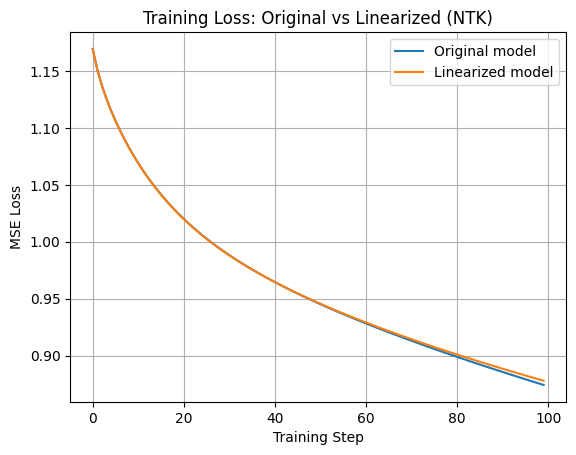

In [4]:
import torch
from torch.func import jvp, functional_call
import torchopt
import matplotlib.pyplot as plt

# --------------------------
# Model + Linearize Function
# --------------------------

class SimpleLinear(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_features, 200),
            torch.nn.ReLU(),
            torch.nn.Linear(200, out_features)
        )


    def forward(self, x):
        return self.linear(x)

# --------------------------
# Setup
# --------------------------

# Initialize model and training data
torch.manual_seed(0)
model = SimpleLinear(in_features=10, out_features=1)
# copy initial parameters, without gradients
# this is important to avoid backpropagation through the model
params_init = {k: v.detach().clone() for k, v in model.named_parameters()}
# Linearize the model
linear_model = linearize(model, params_init)

# Make trainable copies of params
new_params = tuple(model.parameters())  # extract parameters without gradients

learning_rate = 1e-2
# Set up optimizer for original model
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
# Set up optimizer for linearized model
linear_optimizer = torchopt.FuncOptimizer(torchopt.sgd(lr=learning_rate))


# Training data
x = torch.randn(128, 10)
y = torch.randn(128, 1)

# Track losses
losses_orig = []
losses_lin = []

# --------------------------
# Training loop
# --------------------------

for step in range(100):
    # ---- Linearized model ----
    y_lin = linear_model(new_params, x)
    loss_lin = torch.nn.functional.mse_loss(y_lin, y)
    # loss_lin.backward()
    # Update linearized model parameters
    linear_optimizer.step(loss_lin, new_params)

    # ---- Original model ----
    optimizer.zero_grad()
    y_orig = model(x)
    loss_orig = torch.nn.functional.mse_loss(y_orig, y)
    loss_orig.backward()
    optimizer.step()

    # Track
    losses_orig.append(loss_orig.item())
    losses_lin.append(loss_lin.item())

    if step % 10 == 0:
        print(f"Step {step:3d} | Original Loss: {loss_orig.item():.4f} | Linearized Loss: {loss_lin.item():.4f}")
    # After training step
    # for i, (k, v) in enumerate(model.named_parameters()):
        # check if the parameter matches the new_params
        # but ignore the case where the the bias is zero
        # if torch.allclose(v.detach(), new_params[i]) and not k.endswith(".bias"):
            # print(f"Warning: param {k} is matching!")
# --------------------------
# Plot comparison
# --------------------------
plt.plot(losses_orig, label="Original model")
plt.plot(losses_lin, label="Linearized model")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Training Loss: Original vs Linearized (NTK)")
plt.legend()
plt.grid(True)
plt.show()

### Module 

In [ ]:
import optree.pytree as pt
class LinearizedModel(torch.nn.Module):
    """
    A wrapper that linearizes a given model around its initial parameters.
    """
    def __init__(self, base: torch.nn.Module):
        super().__init__()
        self.base = base
        # keep a cpu snapshot
        self._init  = {
            name: param.detach().clone()
            for name, param in base.named_parameters()
        }
        for name, init in self._init.items():
            self.register_parameter(name.replace('.', '_'),
                                    torch.nn.Parameter(init.clone()))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. Get the pytree of DIRECT parameters (θ), avoiding recursion
        #    self._parameters contains only the top-level registered params.
        params_dict = self._parameters
        theta = {k.replace('_', '.'): v for k, v in params_dict.items()}

        # 2. Move initial parameters to the correct device (θ₀)
        device = next(self.parameters()).device
        theta_initial = pt.map(lambda p: p.to(device), self._init)

        # 3. Compute Δθ = θ - θ₀
        delta_theta = pt.map(lambda p, p0: p - p0, theta, theta_initial)

        # 4. jvp as before
        def wrapped(p): return functional_call(self.base, p, (x,))
        f0, lin = jvp(wrapped, (theta_initial,), (delta_theta,))
        return f0 + lin
    

def compute_feature_jacobian(model: torch.nn.Module, x_batch: torch.Tensor) -> torch.Tensor:
    """
    Computes the feature Jacobian of a model with respect to its parameters.

    Args:
        model (nn.Module): The neural network.
        x_batch (Tensor): A batch of input data of shape (n, ...).

    Returns:
        Tensor: The Jacobian matrix J of shape (n, P), where P is the
                total number of parameters in the model.
    """
    # Ensure the model is in eval mode
    model.eval()
    
    # Get a dictionary of the model's parameters
    params = {k: v for k, v in model.named_parameters() if v.requires_grad}

    def f_single(p, x):
        """A function that computes the model's output for a single input `x`
           using the provided parameters `p`."""
        # The unsqueeze/squeeze handles models expecting a batch dimension
        return torch.func.functional_call(model, p, (x.unsqueeze(0),)).squeeze(0)

    def j_single(p, x):
        """Computes the flattened Jacobian for a single input `x`."""
        # Compute the Jacobian with respect to the parameters (argnums=0)
        jac_pytree = torch.func.jacrev(f_single, argnums=0)(p, x)
        # Flatten the PyTree of gradients into a single vector
        return torch.cat([v.flatten() for v in jac_pytree.values()])

    # Use vmap to vectorize the jacobian computation over the batch of inputs
    # in_dims=(None, 0) means: don't map over params, but map over the 0-th
    # dimension of x_batch.
    J = torch.func.vmap(j_single, in_dims=(None, 0))(params, x_batch)
    return J

[000] orig=0.9913  lin=0.9913
[010] orig=0.9893  lin=0.9893
[020] orig=0.9881  lin=0.9881
[030] orig=0.9871  lin=0.9871
[040] orig=0.9861  lin=0.9861
[050] orig=0.9853  lin=0.9853
[060] orig=0.9845  lin=0.9844
[070] orig=0.9837  lin=0.9837
[080] orig=0.9830  lin=0.9830
[090] orig=0.9823  lin=0.9823


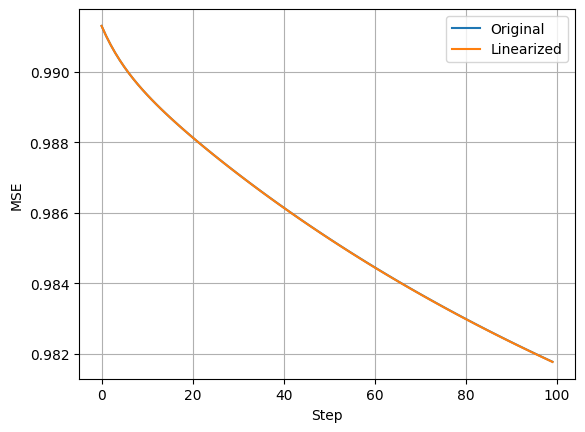

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.func import functional_call, jvp
from core.utils import orthogonal_rows

# --------------------------
# 1) Base model 
# --------------------------

class SimpleNonLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 200),
            nn.ReLU(),
            nn.Linear(200, out_features),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# --------------------------
# 2) Setup
# --------------------------

torch.manual_seed(0)
orig = SimpleNonLinear(10, 1)
lin  = LinearizedModel(orig)   # ntk‐linearized around orig’s init

learning_rate = 1e-2
opt_orig = optim.SGD(orig.parameters(), lr=learning_rate)
opt_lin  = optim.SGD(lin.parameters(),  lr=learning_rate)

x = orthogonal_rows(1000, 10)
y = torch.randn(1000, 1)

J = compute_feature_jacobian(orig, x)  # Shape: (5000, P), where P is the number of parameters
y_resid = y - lin(x)  # Residuals of the linearized model

losses_orig, losses_lin = [], []

# --------------------------
# 3) Training loop
# --------------------------
n_updates = 100
for step in range(n_updates):
    # — linearized model step
    opt_lin.zero_grad()
    y_lin = lin(x)
    loss_lin = nn.functional.mse_loss(y_lin, y)
    loss_lin.backward()
    opt_lin.step()

    # — original model step
    opt_orig.zero_grad()
    y_orig    = orig(x)
    loss_orig = nn.functional.mse_loss(y_orig, y)
    loss_orig.backward()
    opt_orig.step()

    losses_lin.append(loss_lin.item())
    losses_orig.append(loss_orig.item())

    if step % 10 == 0:
        print(f"[{step:03d}] orig={loss_orig:.4f}  lin={loss_lin:.4f}")

# --------------------------
# 4) Plot
# --------------------------

plt.plot(losses_orig, label="Original")
plt.plot(losses_lin,  label="Linearized")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

In [20]:
from core.bias import DiagMatrixRidgeBias, DiagPSDMatrixRidgeBias
from core.estimators import BiasWithMSE
from core.callbacks import WandBCallback
from lightning.pytorch.callbacks import EarlyStopping

num_parameters = sum(p.numel() for p in lin.parameters())
bias_model = DiagMatrixRidgeBias(dim=num_parameters)

bias_estimator = BiasWithMSE(
    predictive_model=lin,
    bias_model=bias_model,
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

dm = FullBatchDataModule(x, y, num_workers=3)

logger = WandbLogger(
    project="inductive-bias",
    name="linearized_model_bias_estimation",
    log_model=False,
    save_dir='../logs',
)

# Train the bias estimator
bias_trainer = Trainer(
    logger=logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=50, mode="min"),
    ],
    max_epochs=5000,
    accumulate_grad_batches=1,
    log_every_n_steps=5,
    accelerator="gpu",
    devices=n_devices,
)
bias_trainer.fit(bias_estimator, dm)


/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/anon/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                | Params | Mode 
-----------------------------------------------------------------
0 | predictive_model | LinearizedModel     | 4.8 K  | train
1 | bias_model       | DiagMatrixRidgeBias | 4.8 K  | train
-----------------------------------------------------------------
9.6 K     Trainable params
0         Non-trainable params
9.6 K     Total params
0.038     Total estimated model params size (MB)
2         Modules in train mode
5         Modules in eval mode
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

bias/Q,▁▃▃▃▃▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████
bias/Q_grad,█▅▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▂▂▂▂▄▃▂▂▃▄▃▃▃
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/loss,█▆▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇████
bias/Q,7.68679
bias/Q_grad,0.0
epoch,1909
train/loss,0.0
trainer/global_step,1909


In [21]:
Q_hat = torch.diag(bias_estimator.bias_model.Q.detach().cpu().clone())
Q_hat.min()

tensor(-2.1095)

In [22]:
from core.utils import is_psd
assert is_psd(Q_hat), "Estimated Q is not PSD"

Matrix is symmetric.


AssertionError: Estimated Q is not PSD

In [55]:
from torch import Tensor

def compute_Q_matrix_ntk(J: Tensor, k: int, eps: float, jit=None) -> Tensor:
    r"""
    Compute the Q matrix for a linearized model based on the Feature Jacobian `J`.

    This constructs Q via eigendecomposition of the empirical NTK G = (1/n) JᵀJ.
    ... (rest of docstring is similar) ...

    Args:
        J (torch.Tensor): Feature Jacobian matrix of shape (n, P).
        k (int): Number of gradient steps (must be >= 1).
        eps (float): Learning rate or step size. Must be < 1 / λ_max.

    Returns:
        torch.Tensor: Symmetric positive-definite Q matrix of shape (P, P).
    """
    n, p = J.shape
    # G is the empirical covariance of the feature map (sometimes called empirical NTK)
    G = J.T @ J / n
    if jit is not None:
        G += jit * torch.eye(p, dtype=G.dtype, device=G.device)

    eigenvals, eigenvecs = torch.linalg.eigh(G)

    max_lr = 1 / eigenvals.max()
    # Adding a small tolerance for floating point issues
    assert eps < max_lr * (1 - 1e-6), f"eps {eps} is >= max lr {max_lr}"

    S = torch.diag(eigenvals)
    I = torch.eye(p, dtype=S.dtype, device=S.device)

    D = S @ torch.linalg.inv(torch.matrix_power(I - eps * S, -k) - I)

    Q = eigenvecs @ D @ eigenvecs.T
    return Q

def compute_delta_theta_closed_form(J: Tensor, y_residual: Tensor, Q: Tensor) -> Tensor:
    r"""
    Compute closed-form solution for the parameter update Δθ.

    Minimizes: (1/n) * ||y_residual - J Δθ||² + Δθᵀ Q Δθ

    Solution: Δθ* = (JᵀJ + nQ)⁻¹ Jᵀy_residual

    Args:
        J (torch.Tensor): Feature Jacobian matrix of shape (n, P).
        y_residual (torch.Tensor): Target residual vector of shape (n,).
        Q (torch.Tensor): Penalty matrix of shape (P, P).

    Returns:
        torch.Tensor: Solution vector Δθ* of shape (P,).
    """
    n = J.shape[0]

    # Form the matrix JᵀJ + nQ
    A = J.T @ J + n * Q  # shape: (P, P)

    # Right-hand side: Jᵀ y_residual
    b = J.T @ y_residual  # shape: (P,)

    # Solve the linear system for the parameter update
    delta_theta_star = torch.linalg.solve(A, b)  # shape: (P,)

    return delta_theta_star

# J = torch.func.linearize(lin, init_on_dev)(x)  #
k = n_updates  # Number of gradient steps
eps = learning_rate  # Learning rate
Q = compute_Q_matrix_ntk(J, k, eps, jit=None)  
c = compute_delta_theta_closed_form(J, y_resid, Q)
print(c.shape)  # Should match the shape of the parameters in the linearized model
print(c)


_LinAlgError: linalg.inv: The diagonal element 1 is zero, the inversion could not be completed because the input matrix is singular.

In [24]:
from core.utils import is_psd
assert is_psd(J.T @ J / x.shape[0]), "JᵀJ is not PSD"

Matrix is symmetric.


In [25]:
assert is_psd(Q), "Theoretical Q is not PSD"

Matrix is symmetric.


In [26]:
# J = compute_feature_jacobian(orig, x)
evals = torch.linalg.eigvalsh(J.T @ J / J.shape[0])
evals.max() / evals.min()

tensor(-44805296., grad_fn=<DivBackward0>)

In [27]:
print(J.shape)  # (5000, P) where P is the number of parameters in `orig`
print((J @ J.T).shape ) # (5000, 5000)
print((J.T @ J / J.shape[0]).shape) # (P, P)

torch.Size([1000, 2401])
torch.Size([1000, 1000])
torch.Size([2401, 2401])


In [30]:
is_psd(J.T @ J / J.shape[0])

Matrix is symmetric.


True

In [33]:
import optree

def get_delta_theta_from_model(model: LinearizedModel) -> torch.Tensor:
    # Get the pytree of current parameters (θ)
    params_dict = model._parameters
    theta = {k.replace('_', '.'): v for k, v in params_dict.items()}

    # 1. Compute the tree of differences (Δθ)
    #    The lambda handles detaching and device movement simultaneously.
    delta_tree = optree.tree_map(
        lambda p, p0: p.detach() - p0.to(p.device),
        theta,
        model._init
    )

    # 2. Flatten the tree to a list of tensors and concatenate
    leaves, _ = optree.tree_flatten(delta_tree)
    return torch.cat([leaf.flatten() for leaf in leaves])

delta_actual = get_delta_theta_from_model(lin)
print(delta_actual.shape)  # Should match the shape of c
print(delta_actual)


torch.Size([2401])
tensor([ 0.0002, -0.0009,  0.0015,  ..., -0.0003,  0.0026,  0.0014])


In [54]:
torch.isclose(delta_actual, c.squeeze(), atol=1e-3).sum() / delta_actual.numel()

tensor(0.8188)